# Experiment with controlling over the representation 

1. Optimal control idea: rep A and memorized rep B; find best control to get A to B. 
2. Neural network control: use a NN to do just that, and let the output sheet of neurons operate on the tangent space of the representation manifold at any point
- this is where we can take on the connectome. 

In the end, we want this project to be useful in driving experiments to test how this connects to the SC SO(3) representation. 
- e.g., tuning
- e.g., connectome

en passe, level up the biological neural constraints

Then, we may want to ask: what would the connectome, behavior, and learning look like for different reps for the same task? What would be optimal given biological mechanistic constraints (different efforts moving in each direction)?

At the end, we want to discuss what effective reps may arise for different tasks and constraints. 

In [2]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torch.optim import lr_scheduler as LR
from torch.utils.data import Dataset, DataLoader
import plotly.express as px
from functools import partial
from SimulateDatasets.ContrastiveGenerator import ContrastiveGenerator, AR1_ordered_data_gen, OrderedDataset, SampledDataset
from Network_models.CANTrainer import CANTrainer
from Network_models.PartitionedRNN import PartitionedNet
from utils.path_settings import *
import seaborn as sns
import os
from Rotations import integrate_velocities, exp_quat, q_mult, integrate_quat_sequential
from Plots.AttractorPlots import *
from Plots.globe_plots import *
import utils

2025-01-31 16:02:43.526021: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-31 16:02:43.606140: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-31 16:02:43.645805: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-31 16:02:43.646084: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-31 16:02:43.700477: I tensorflow/core/platform/cpu_feature_gua

/home/timmy/nonnormal/dummy/mental-rotations
loading


# Inverse Model to generate data

First, let's train a simple mapping between our favorite rep of the space to the neural representation. This is done by a very simple neural network, just in case the transformation is not linear. 

remember the space of representation is depedent on the activation functino. The simplest thing we could do is to just copy it from the net!

In [3]:
# adjustable knobs 
knobs = {
        "batch_size" : 4096,
        "mini_batch_size" : 256,
        "repUnits" : 128,
        "model" : "PartitionedRNN", # or "PartitionedCTRNN"
        # "model": "FlexibleRNN",
        "manifold" : "s", #"custom", # or "S"
        # "manifold" : "custom",
        "dim" : 3,
        "zeroNullRep" : False,
        "zeroNullInput" : False,
        "biasRep" : True,
        "biasInput" : True,
        "hihr_identity": False, 
        "cParam" : True,
        "nonlinearity" : "tanh",
        # "nonlinearity": "BiologicalReLU",
        # "nonlinearity": "BiologicalTanh",
        # "nonlinearity": "relu",
        # "nonlinearity": "NormedReLU", 
        "inputEnveloping" : False,
        "loss" : "infonce",
        "triplet_weight" : 0, # only turn if loss is triplet
        "normalize" : False,
        "similarity_kernel" : None,
        "weight_decay_thresh" : -10,
        "L2norm_scalar": 0,
        "manifold_name": "ModifiedRingManifold",
        # "similarity_kernel": "cosine", 
        "similarity_kernel": "euclidean",
        "capacity": False, 
        "manifold_params": {
            "R":1, 
            "A":0.2, 
            "n":5,
        },
        "temperature": 0.7, 
        "invariance_weight": 1,  
        # "bidirectional": False, 
        "epsilon_max":0.1,
    }
for key, value in knobs.items():
    exec(f"{key} = {f"{value}" if type(value) != str else f'"{value}"'}")
if knobs['hihr_identity'] == False:
    knobs['hihr_identity'] = None
if knobs["L2norm_scalar"] == 0:
    knobs["L2norm_scalar"] = None
if knobs["similarity_kernel"] == "cosine":
    knobs["similarity_kernel"] = None
exclude = ["batch_size", "mini_batch_size", "triplet_weight", "loss", "weight_decay_thresh"]
if knobs["manifold"].lower() in ["s", "t"]: 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds", 
        "manifold_name": "Sphere" if knobs["manifold"].lower() == "s" else "Torus",
        "manifold_params": {"dim": knobs["dim"], 
                            }
    }
    exclude.extend(["manifold_name", "manifold_params"])


if knobs["manifold"].lower() == "custom": 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds",
        "manifold_name": knobs["manifold_name"],
        "manifold_params": knobs["manifold_params"]
    }
configs, data_specs = utils.knobs2specs_CAN(knobs)



In [6]:
data_gen = ContrastiveGenerator(data_specs)

# or alternatively, define trainer and load a model
trainer = CANTrainer(configs)
path = utils.load_from_lookup(configs)
try: 
    trainer.load_model(path)
    print("Model loaded via train")
except Exception as e:
    print(e)    
    print("No model to load")
    trainer.load_model(configs["save_path"][:-9] + "best_model.pth")

rnn = trainer.model.to("cuda")
rnn.eval()
rnn.rnn.eval()
torch.save(rnn, path.replace("model.pth", "model_full.pth"))

input_connected: True
1
no scheduler
Model loaded via train


In [7]:
path

'/home/timmy/nonnormal/dummy/mental-rotations/saved_models/CAN/2025-01-17-06-22/model.pth'

Now, Generate some data and check that the sampled dataset spans the space we are looking at. 

In [5]:
d = data_gen.generate_data(32, disregard_n_samples=False)
dpositions = d.positions.cpu().numpy()
# plt.scatter(dpositions[:, 0], dpositions[:, 1], alpha= 0.1)

tensor(0.0229, device='cuda:0')


Now proceed to training the model that maps from the representation to the neural representation. For the simplicity of this deal, no extra trainer is defined. 

In [6]:
class CosineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta], dim=1)
        return torch.cos(x * self.theta)
class CosineSineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineSineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta] + [torch.sin(x * theta) for theta in self.theta], dim=1)
        return torch.cat([torch.cos(x * self.theta), torch.sin(x * self.theta)], dim=1)
    
def expand_trig(theta):
    """
    theta: torch.tensor(batch_size, dim): thetas of different dimensions
    """
    return torch.cat([torch.cos(theta), torch.sin(theta)], dim=1)

def pos2theta(y): 
    dim = y.shape[-1]//2
    theta = torch.zeros((*y.shape[:-1], dim))
    for i in range(dim):
        theta[..., i] = torch.atan2(y[..., i + dim], y[..., i])
    return theta


In [7]:
rep_only = False
mapnet = nn.Sequential(
    # CosineActivation(theta=np.pi/2),
    # ArcCosineActivation(theta=np.pi/2),
    CosineSineActivation(theta=[0.5, 1, 2]),
    nn.Linear(dpositions.shape[1] * 6, 128), 
    nn.ReLU(),
    # CosineSineActivation(theta=[0.5, 1, 2]),
    # nn.Linear(128, 128),
    # nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    # nn.Linear(dpositions.shape[1], rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    rnn.rnn.nonlinearity_fn if rnn.rnn.nonlinearity_fn is not torch.nn.functional.tanh else nn.Tanh(), 
)

In [65]:
dpositions.shape

(32, 1)

In [8]:
readoutnet = nn.Sequential(
    nn.Linear(rnn.rnn.rep_units, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, dpositions.shape[1] * 2),
)

In [9]:
# TRAIN A MAPNET
p_resample = 0.02
epochs = 100
mini_batch_size = 256
optimizer = optim.Adam(mapnet.parameters(), lr=0.003)

d = data_gen.generate_data(32, disregard_n_samples=False) if dim == 2 else data_gen.generate_data(1000, disregard_n_samples=False)
X_val = d.positions
with torch.no_grad():
    Y_val = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]

d = data_gen.generate_data(64, disregard_n_samples=False) if dim == 2 else data_gen.generate_data(10000, disregard_n_samples=False)
X_train = d.positions + (torch.randn_like(d.positions) < 0) * 2 * np.pi - (torch.randn_like(d.positions) < 0) * 2 * np.pi
with torch.no_grad():
    Y_train = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]

train_set = torch.utils.data.TensorDataset(X_train, Y_train)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))
val_set = torch.utils.data.TensorDataset(X_val, Y_val)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))

train_losses = []
val_losses = []

mapnet = mapnet.train().float()
mapnet.to("cuda")
for epoch in range(epochs):
    for X, Y in train_loader:
        X, Y = X.to("cuda").float(), Y.to("cuda").float()
        optimizer.zero_grad()
        Y_hat = mapnet(X)
        loss = F.mse_loss(Y_hat, Y)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    for X, Y in val_loader:
        X, Y = X.to("cuda").float(), Y.to("cuda").float()
        
        Y_hat = mapnet(X)
        loss = F.mse_loss(Y_hat, Y)
        val_losses.append(loss.item())
    if torch.rand(1) < p_resample:
        d = data_gen.generate_data(64, disregard_n_samples=False) if dim == 2 else data_gen.generate_data(10000, disregard_n_samples=False)
        X_train = d.positions + (torch.randn_like(d.positions) < 0) * 2 * np.pi - (torch.randn_like(d.positions) < 0) * 2 * np.pi
        with torch.no_grad():
            Y_train = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]
        train_set = torch.utils.data.TensorDataset(X_train, Y_train)
        train_loader = torch.utils.data.DataLoader(train_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Train Loss: {train_losses[-1]}, Val Loss: {val_losses[-1]}")

tensor(0.0484, device='cuda:0')
tensor(0.0754, device='cuda:0')
Epoch 0, Train Loss: 0.004958702716976404, Val Loss: 0.006303891073912382
Epoch 10, Train Loss: 0.004462458658963442, Val Loss: 0.005189221352338791
Epoch 20, Train Loss: 0.004117439966648817, Val Loss: 0.005596738308668137
tensor(0.0601, device='cuda:0')
Epoch 30, Train Loss: 0.004686512053012848, Val Loss: 0.005514228716492653
Epoch 40, Train Loss: 0.00376399839296937, Val Loss: 0.0053340657614171505
tensor(0.0649, device='cuda:0')
Epoch 50, Train Loss: 0.005270398687571287, Val Loss: 0.006626896094530821
Epoch 60, Train Loss: 0.004259742796421051, Val Loss: 0.0054526436142623425
Epoch 70, Train Loss: 0.0037545282393693924, Val Loss: 0.005881243851035833
Epoch 80, Train Loss: 0.00639189500361681, Val Loss: 0.005702010355889797
tensor(0.0676, device='cuda:0')
Epoch 90, Train Loss: 0.005951525177806616, Val Loss: 0.005633990280330181


In [10]:
#TRAIN A READOUTNET
p_resample = 0.1
epochs = 100
mini_batch_size = 256
optimizer = optim.Adam(readoutnet.parameters(), lr=0.003)
rep_only = True
d = data_gen.generate_data(32, disregard_n_samples=False) if dim == 2 else data_gen.generate_data(1000, disregard_n_samples=False)
Y_val = d.positions
Y_val = expand_trig(d.positions)
with torch.no_grad():
    X_val = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]

d = data_gen.generate_data(64, disregard_n_samples=False) if dim == 2 else data_gen.generate_data(10000, disregard_n_samples=False)
Y_train = d.positions
Y_train = expand_trig(d.positions)
with torch.no_grad():
    X_train = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]

train_set = torch.utils.data.TensorDataset(X_train, Y_train)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))
val_set = torch.utils.data.TensorDataset(X_val, Y_val)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))

train_losses = []
val_losses = []

readoutnet = readoutnet.train().float()
readoutnet.to("cuda")
for epoch in range(epochs):
    for X, Y in train_loader:
        X, Y = X.to("cuda").float(), Y.to("cuda").float()
        optimizer.zero_grad()
        Y_hat = readoutnet(X)
        loss = F.mse_loss(Y_hat, Y)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    for X, Y in val_loader:
        X, Y = X.to("cuda").float(), Y.to("cuda").float()
        
        Y_hat = readoutnet(X)
        loss = F.mse_loss(Y_hat, Y)
        val_losses.append(loss.item())
    if torch.rand(1) < p_resample:
        d = data_gen.generate_data(64, disregard_n_samples=False) if dim == 2 else data_gen.generate_data(10000, disregard_n_samples=False)
        Y_train = d.positions
        Y_train = expand_trig(d.positions)
        with torch.no_grad():
            X_train = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]
        train_set = torch.utils.data.TensorDataset(X_train, Y_train)
        train_loader = torch.utils.data.DataLoader(train_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))
    if epoch % 10 == 0:
      print(f"Epoch {epoch}, Train Loss: {train_losses[-1]}, Val Loss: {val_losses[-1]}")

tensor(0.0996, device='cuda:0')
tensor(0.0735, device='cuda:0')
Epoch 0, Train Loss: 0.0008670201059430838, Val Loss: 0.0008974773227237165
Epoch 10, Train Loss: 0.0007566913845948875, Val Loss: 0.00104882987216115
tensor(0.0736, device='cuda:0')
Epoch 20, Train Loss: 0.0002955996023956686, Val Loss: 0.0005171959637664258
tensor(0.0805, device='cuda:0')
Epoch 30, Train Loss: 0.001314898137934506, Val Loss: 0.0018335467902943492
tensor(0.0801, device='cuda:0')
tensor(0.0664, device='cuda:0')
tensor(0.0562, device='cuda:0')
Epoch 40, Train Loss: 0.0004151512694079429, Val Loss: 0.0007716987747699022
tensor(0.0786, device='cuda:0')


KeyboardInterrupt: 

In [250]:
X_train.shape

torch.Size([10000, 128])

In [11]:
# let's get a uniform grid of points
d = data_gen.generate_data(64, disregard_n_samples=False) if dim == 2 else data_gen.generate_data(10000, disregard_n_samples=False)
X_train = d.positions + (torch.randn_like(d.positions) < 0) * 2 * np.pi - (torch.randn_like(d.positions) < 0) * 2 * np.pi
rep_only = False
with torch.no_grad():
    Y_train = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]


xy = X_train
reps = Y_train
# reps += rnn.rnn.c.reshape(1, -1)
reps = reps - reps.mean(dim=0).detach()
# reps = F.normalize(reps, p=2, dim=1)

u, s, v = torch.svd(reps)

fig = plt.figure()
# Project to top 3 singular vectors
PCs_all = reps @ v[:, :]
b = 0
PCs = PCs_all[:, b:b + 3].cpu()

if manifold == "s":
    c = (torch.acos(torch.clamp(d.quats[:, 0],-1, 1))).cpu().numpy() * 2
    cx = d.quats[:, 1:]
    cx = (cx/cx.norm(dim = -1, keepdim=True)).cpu().numpy()
    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c
                        # set colorbar to viridis
                        , color_continuous_scale = "turbo", opacity=0.4,
                        # ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))

    red_dot_position = -((rnn_test.rnn.c + offset) @ v[:, b:b + 3]).cpu().detach()
    fig1.add_scatter3d(
        x=[red_dot_position[0]], 
        y=[red_dot_position[1]], 
        z=[red_dot_position[2]], 
        mode="markers", 
        marker=dict(size=10, color="red"), 
        name="Red Dot",
        showlegend=False
    )
    fig1.update_layout(coloraxis_colorbar=dict(title="theta"))

    fig1.show()
    labs = ["axis_x", "axis_y", "axis_z"]
    for i in range(3): 
        fign = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = cx[:, i]
                        # set colorbar to viridis
                        ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
        ptsize = 2
        fign.update_traces(marker=dict(size=ptsize))

        red_dot_position = -((rnn_test.rnn.c+offset) @ v[:, b:b + 3]).cpu().detach()
        fign.add_scatter3d(
            x=[red_dot_position[0]], 
            y=[red_dot_position[1]], 
            z=[red_dot_position[2]], 
            mode="markers", 
            marker=dict(size=10, color="red"), 
            name="Red Dot",
            showlegend=False
        )
        fign.update_layout(coloraxis_colorbar=dict(title=labs[i]))
        fign.show()
elif manifold == "custom":
    c = data.theta.cpu().numpy()
    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c
                        # set colorbar to viridis
                        , color_continuous_scale = "turbo", opacity=0.4,
                        # ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))

    red_dot_position = -((rnn_test.rnn.c + offset) @ v[:, b:b + 3]).cpu().detach()
    fig1.add_scatter3d(
        x=[red_dot_position[0]], 
        y=[red_dot_position[1]], 
        z=[red_dot_position[2]], 
        mode="markers", 
        marker=dict(size=10, color="red"), 
        name="Red Dot",
        showlegend=False
    )
    fig1.update_layout(coloraxis_colorbar=dict(title="theta"))

    fig1.show()

else: 
    c = xy.cpu()
    # c0 = abs(c[:, 0])
    c0 = c[:, 0]
    while max(c0)> np.pi or min(c0) < -np.pi:
        c0 = c0 + 2 * np.pi * (c0 < -np.pi) - 2 * np.pi * (c0 > np.pi)

    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c0
                        # set colorbar to viridis
                        ,color_continuous_scale = "turbo", opacity=0.4,  
                        )



    if dim == 2 or dim == 3: 
        c1 = c[:, 1]
        while max(c1)> np.pi or min(c1) < -np.pi:
            c1 = c1 + 2 * np.pi * (c1 < -np.pi) - 2 * np.pi * (c1 > np.pi)


        #jot a 3D plot by px
        fig2 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c1
                            # set colorbar to viridis
                            ,color_continuous_scale = "turbo", opacity=0.4
                            )
    if dim == 3: 
        c2 = c[:, 2]
        while max(c2)> np.pi or min(c2) < -np.pi:
            c2 = c2 + 2 * np.pi * (c2 < -np.pi) - 2 * np.pi * (c2 > np.pi)


        #jot a 3D plot by px
        fig3 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c2
                            # set colorbar to viridis
                            ,color_continuous_scale = "turbo", opacity=0.4
                            )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))
    fig1.show()
    if dim == 2 or dim == 3:
        fig2.update_traces(marker=dict(size=ptsize))
        fig2.show()
    if dim == 3:
        fig3.update_traces(marker=dict(size=ptsize))
        fig3.show()


tensor(0.0616, device='cuda:0')


<Figure size 640x480 with 0 Axes>

In [14]:
torch.save(mapnet, configs["save_path"].replace("model.pth", "mapnet.pth"))

In [254]:
mapnet = torch.load(configs["save_path"].replace("model.pth", "mapnet.pth"))
readoutnet = torch.load(configs["save_path"].replace("model.pth", "readoutnet.pth"))
mapnet.eval()
readoutnet.eval()
mapnet.to("cuda")
readoutnet.to("cuda")

Sequential(
  (0): Linear(in_features=128, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=2, bias=True)
)

In [44]:
# let's get a uniform grid of points
n_points = 1000
if dim == 1:
    x = np.linspace(-1, 1, n_points) * np.pi
    xy = torch.tensor(x).to("cuda").float().reshape(-1, 1)
elif dim == 2:
    n_points = 100
    x = np.linspace(-1, 1, n_points) * np.pi
    y = np.linspace(-1, 1, n_points) * np.pi
    x_grid, y_grid = np.meshgrid(x, y)
    xy = np.stack([x_grid.flatten(), y_grid.flatten()], axis=1)
    xy = torch.tensor(xy).to("cuda").float()
mapnet = mapnet.float()
reps = mapnet(xy).detach()
reps = reps - reps.mean(dim=0).detach()
u, s, v = torch.svd(reps)

fig = plt.figure()
# Project to top 3 singular vectors
PCs_all = reps @ v[:, :]
b = 0
PCs = PCs_all[:, b:b + 3].cpu()

if manifold == "s":
    c = (torch.acos(torch.clamp(d.quats[:, 0],-1, 1))).cpu().numpy() * 2
    cx = d.quats[:, 1:]
    cx = (cx/cx.norm(dim = -1, keepdim=True)).cpu().numpy()
    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c
                        # set colorbar to viridis
                        , color_continuous_scale = "turbo", opacity=0.4,
                        # ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))

    red_dot_position = -((rnn_test.rnn.c + offset) @ v[:, b:b + 3]).cpu().detach()
    fig1.add_scatter3d(
        x=[red_dot_position[0]], 
        y=[red_dot_position[1]], 
        z=[red_dot_position[2]], 
        mode="markers", 
        marker=dict(size=10, color="red"), 
        name="Red Dot",
        showlegend=False
    )
    fig1.update_layout(coloraxis_colorbar=dict(title="theta"))

    fig1.show()
    labs = ["axis_x", "axis_y", "axis_z"]
    for i in range(3): 
        fign = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = cx[:, i]
                        # set colorbar to viridis
                        ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
        ptsize = 2
        fign.update_traces(marker=dict(size=ptsize))

        red_dot_position = -((rnn_test.rnn.c+offset) @ v[:, b:b + 3]).cpu().detach()
        fign.add_scatter3d(
            x=[red_dot_position[0]], 
            y=[red_dot_position[1]], 
            z=[red_dot_position[2]], 
            mode="markers", 
            marker=dict(size=10, color="red"), 
            name="Red Dot",
            showlegend=False
        )
        fign.update_layout(coloraxis_colorbar=dict(title=labs[i]))
        fign.show()
elif manifold == "custom":
    c = data.theta.cpu().numpy()
    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c
                        # set colorbar to viridis
                        , color_continuous_scale = "turbo", opacity=0.4,
                        # ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))

    red_dot_position = -((rnn_test.rnn.c + offset) @ v[:, b:b + 3]).cpu().detach()
    fig1.add_scatter3d(
        x=[red_dot_position[0]], 
        y=[red_dot_position[1]], 
        z=[red_dot_position[2]], 
        mode="markers", 
        marker=dict(size=10, color="red"), 
        name="Red Dot",
        showlegend=False
    )
    fig1.update_layout(coloraxis_colorbar=dict(title="theta"))

    fig1.show()

else: 
    c = xy.cpu()
    # c0 = abs(c[:, 0])
    c0 = c[:, 0]
    while max(c0)> np.pi or min(c0) < -np.pi:
        c0 = c0 + 2 * np.pi * (c0 < -np.pi) - 2 * np.pi * (c0 > np.pi)

    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c0
                        # set colorbar to viridis
                        ,color_continuous_scale = "turbo", opacity=0.4,  
                        )



    if dim == 2 or dim == 3: 
        c1 = c[:, 1]
        while max(c1)> np.pi or min(c1) < -np.pi:
            c1 = c1 + 2 * np.pi * (c1 < -np.pi) - 2 * np.pi * (c1 > np.pi)


        #jot a 3D plot by px
        fig2 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c1
                            # set colorbar to viridis
                            ,color_continuous_scale = "turbo", opacity=0.4
                            )
    if dim == 3: 
        c2 = c[:, 2]
        while max(c2)> np.pi or min(c2) < -np.pi:
            c2 = c2 + 2 * np.pi * (c2 < -np.pi) - 2 * np.pi * (c2 > np.pi)


        #jot a 3D plot by px
        fig3 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c2
                            # set colorbar to viridis
                            ,color_continuous_scale = "turbo", opacity=0.4
                            )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))
    fig1.show()
    if dim == 2 or dim == 3:
        fig2.update_traces(marker=dict(size=ptsize))
        fig2.show()
    if dim == 3:
        fig3.update_traces(marker=dict(size=ptsize))
        fig3.show()


<Figure size 640x480 with 0 Axes>

In [12]:
torch.save(mapnet, configs["save_path"].replace("model.pth", "mapnet.pth"))

In [13]:
torch.save(readoutnet, configs["save_path"].replace("model.pth", "readoutnet.pth"))

That looks acceptable enough. Now, with this, we can check out the controller

but before that, quickly validate the attractness of the representation

In [19]:
sigma_scalar = np.linspace(0, 1, 10)
dw = torch.zeros(len(sigma_scalar), 1000)
for i, scalar in enumerate(sigma_scalar): 
    noise = torch.randn_like(reps[:, -rnn.rnn.rep_units:], device="cuda") * scalar
    dw[i] = rnn.rnn.get_dW(reps[:, -rnn.rnn.rep_units:].double()+noise.double()).norm(dim=1)


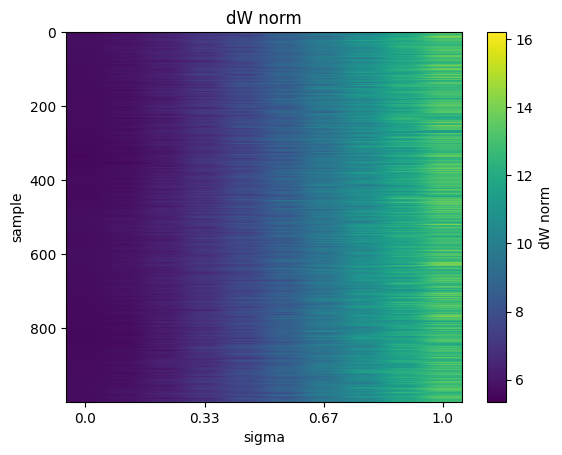

In [20]:
plt.imshow(dw.detach().cpu().numpy().T, aspect="auto")
plt.xticks(np.arange(10), sigma_scalar)
plt.xlabel("sigma")
plt.xticks(np.linspace(0, 9, 4), np.round(np.linspace(sigma_scalar[0], sigma_scalar[-1], 4), 2))
plt.ylabel("sample")
plt.title("dW norm")
# label the colorbar
cbar = plt.colorbar()
cbar.set_label("dW norm")
plt.show()

Now it's time to define the dataset to train the controller with.

all we need is a bunch of points, like a graph, to control to and from. 

hence, for training, we don't even need to use the inverse model we just trained. 

# Controller Dataset

In [14]:
model_path = configs["save_path"].replace("model.pth", "model_full.pth")

In [15]:
from Network_models.CTrainer import CTrainer_CAN
from SimulateDatasets.ContrastiveGenerator import ControlGenerator

In [16]:
torch.save(rnn, configs["save_path"].replace("model.pth", "model_full.pth"))

In [98]:
batch_size = 2048
mini_batch_size = 256
model_specs = {
    "model_name": "ControlNetCAN",
    "model_path": "Network_models.PIDController",
    "model_params":{
        "rep_net_path": configs["save_path"].replace("model.pth", "model_full.pth"),
        "rep_units_only": True, 
        "recurrent_control": False, 
        # "activation": "BiologicalReLU",
        "activation": "ReLU", 
        "hidden_control_dim": 128, 
    }
}

optimizer_specs = {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.003,
    }
}

trainer_config = {
    "model_specs": model_specs,
    "optimizer_specs": optimizer_specs,
    "control_period": 8,
    "random_initial_condition": True,
    "additional_loss": ["final_distance", "control_norm"]#, "state_norm"], 
    # "additional_loss": ["control_norm"], # choices: "state_norm", "control_norm" 
}

model_path = f"/controller_CAN/{model_specs['model_name']}_{model_specs['model_params']['activation']}_{model_specs['model_params']['hidden_control_dim']}_net{model_specs['model_params']['rep_net_path'].split('/')[-3]}"

trainer_config = trainer_config | {
    "save_path": MODEL_SAVE_PATH + model_path + "/",
    "check_path": MODEL_SAVE_PATH + model_path + "/",
    "log_path": LOG_PATH + model_path + "/",
}

data_gen_config = {
    "mini_batch_size": mini_batch_size,
    "contrastive_generator": data_gen, 
    "rep_only": True, 
}

import time
print(f"batch_size: {batch_size}, mini_batch_size: {mini_batch_size}"), "state_norm"
training_args = {
    "data_gen": ControlGenerator(data_gen_config),
    "batch_size": batch_size, 
    "mini_batch_size": mini_batch_size, 
    "epochs_to_calculate": 10,
    "epochs": 300, 
    "load_upper": 47,
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "verbose": True,
    "replacement_tolerance": 0.1,
}

trainer = CTrainer_CAN(trainer_config)
time_start = time.time()

for path in [trainer_config["save_path"], trainer_config["check_path"], trainer_config["log_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = trainer_config["save_path"] + "model.pth"
print(f"tensorboard --logdir {trainer_config['log_path']}")

batch_size: 2048, mini_batch_size: 256
no scheduler
['final_distance', 'control_norm']
tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/controller_CAN/ControlNetCAN_ReLU_128_netrepUnits128_modelPartitionedRNN_manifoldt_dim1_zeroNullRep0_zeroNullInput0_biasRep0_biasInput0_cParam1_nonlinearityBiologicalTanh_inputEnveloping0_normalize0_similarity_kerneleuclidean_capacity0/


In [99]:
# trainer.control_period = 16
# trainer.optimizer = optim.Adam(trainer.model.parameters(), lr=0.0001)
trainer.train(**training_args)

batch_size: 2048, mini_batch_size: 256
tensor(0.0419, device='cuda:0', dtype=torch.float64)
cuda:0
torch.Size([1000, 256])
tensor(0.0828, device='cuda:0', dtype=torch.float64)
cuda:0
torch.Size([1000, 256])
Epoch 0, learning rate: 0.003, validation loss: 76.77414608871709
Epoch 0, training loss: 91.09866730173283, validation loss: 76.77414608871709
Epoch 1, training loss: 67.70983943213338, validation loss: 60.34579322678638
Epoch 2, training loss: 53.81843357275511, validation loss: 48.42794058722503
Epoch 3, training loss: 40.76102214352943, validation loss: 35.76961486747859
Epoch 4, training loss: 31.766213184105705, validation loss: 31.30187263549547
Epoch 5, training loss: 28.101797109298783, validation loss: 25.452780818822973
Epoch 6, training loss: 24.454265909437048, validation loss: 24.435423540579087
Epoch 7, training loss: 24.62264671086047, validation loss: 24.03084777063259
Epoch 8, training loss: 23.429093777035902, validation loss: 23.068967930620303
Epoch 9, training 

KeyboardInterrupt: 

In [101]:
save_path = trainer_config["save_path"][:-1] + "_" + "_".join(trainer_config['additional_loss']) + "/"

In [102]:
os.makedirs(save_path, exist_ok=True)
trainer.save_model(save_path + "model.pth")

In [103]:
trainer.load_model(save_path + "model.pth")

In [104]:
a = torch.randint(0, reps.shape[0], (1,)).item()
b = torch.randint(0, reps.shape[0], (1,)).item()
init = reps[a:a+1]
target = reps[b:b+1][:, -rnn.rnn.rep_units:]


In [41]:
init = mapnet(torch.tensor([[-2.81]]).to("cuda").float())
init = mapnet(torch.linspace(-3.14, 3.14, 100).to("cuda").float().reshape(-1, 1))
target = mapnet(torch.linspace(-3.14, 3.14, 100).to("cuda").float().reshape(-1, 1))[:, -128:]

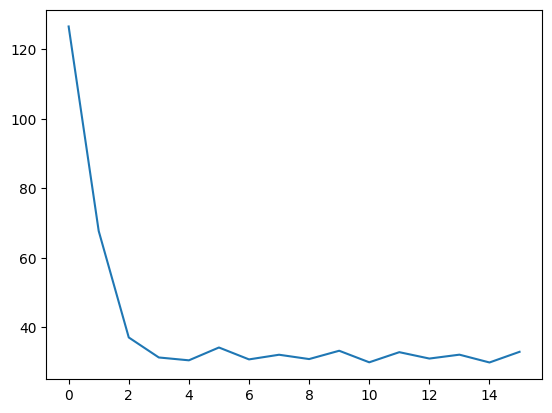

In [105]:
trainer.model.rep_net.float()
hi, control_trajectory, error_trajectory, ht = trainer.model(init.float(), target.float(), control_period = 16, return_control_trajectory=True)
plt.plot(error_trajectory[0].cpu().detach().numpy())

In [106]:
positions = readoutnet(hi[:, :, -128:].float())
pos0 = pos2theta(readoutnet(init[:, -128:].float()))
pos_traj = pos2theta(positions)
pos1 = pos2theta(readoutnet(target.float()))

torch.Size([1, 1])
torch.Size([1, 17, 1])
torch.Size([1, 1])


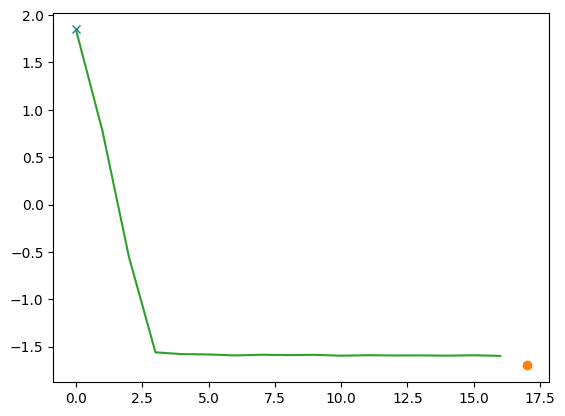

In [107]:
# plot the trajectory: 
tensors = [pos0, pos_traj, pos1]
tensors[1] = torch.cat((tensors[0].unsqueeze(1), tensors[1]), dim = -2)
for i, tensor in enumerate(tensors): 
    print(tensor.shape)
    tensors[i] = tensor.cpu().detach().numpy()
if tensors[0].shape[-1] == 2:
    plt.scatter(tensors[0][:, 0], tensors[0][:, 1], label="initial", marker="x")
    plt.scatter(tensors[-1][:, 0], tensors[-1][:, 1], label="target", marker="o")
    plt.plot(tensors[1][:, 0], tensors[1][:, 1], label="trajectory")
elif tensors[0].shape[-1] == 1:
    t = np.arange(tensors[1].shape[1] + 1)
    plt.plot(t[0].repeat(tensors[0].shape[0]), tensors[0], label="initial", marker="x")
    plt.plot(t[-1].repeat(tensors[0].shape[0]), tensors[-1], label="target", marker="o")
    for i in range(tensors[1].shape[0]):
        plt.plot(t[:-1], tensors[1][i], label="trajectory")

Visualize 1D ring control neurons. 

In [108]:
# plot tuning curve: 
sample_from_num = 16
sample_to_num = 16
from_angle = np.linspace(-np.pi, np.pi, sample_from_num)
from_angle = np.repeat(from_angle, sample_to_num)
to_angle = np.linspace(-np.pi, np.pi, sample_to_num)
to_angle = np.tile(to_angle, sample_from_num)
from_reps = mapnet(torch.tensor(from_angle).to("cuda").float().reshape(-1, 1)).detach()
to_reps = mapnet(torch.tensor(to_angle).to("cuda").float().reshape(-1, 1)).detach()[:, -128:]

hi, control_trajectory, error_trajectory, ht = trainer.model(from_reps, to_reps, control_period = 16, return_control_trajectory=True)

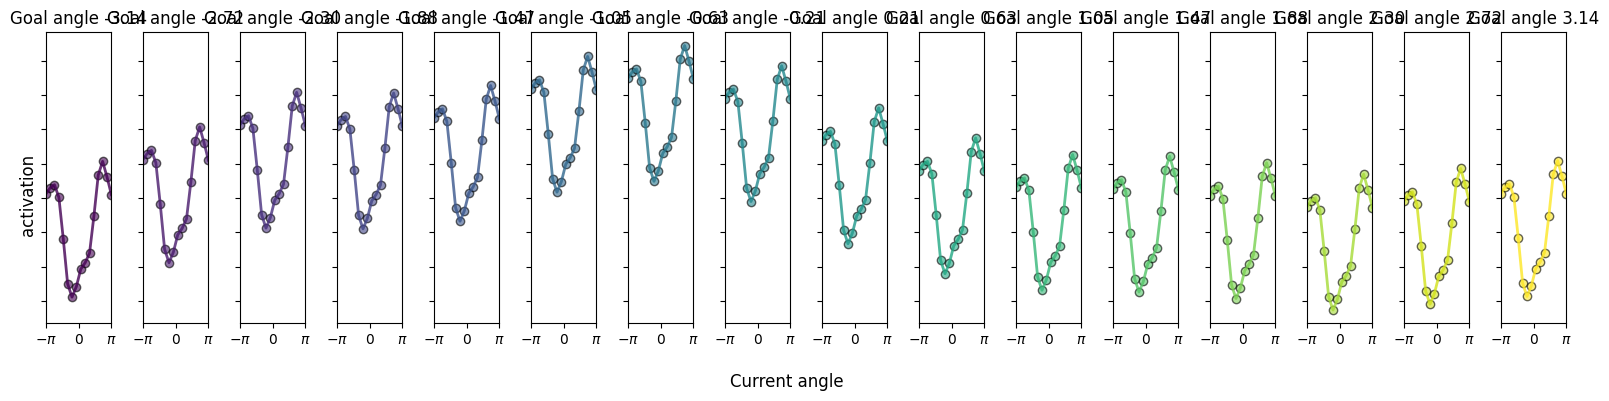

In [109]:
import matplotlib.colors as mcolors

neuron_id = np.random.randint(128)
# Simulated data
num_cells = 16  # Number of cells
num_samples = 16  # Number of samples
angles = np.linspace(-np.pi, np.pi, num_samples)  # Headings
spike_rates = [ht[i:i + num_samples, 0, neuron_id].cpu().detach().numpy() for i in range(0, num_samples * num_cells, num_cells)]  # Spike rates

# Plotting
fig, axes = plt.subplots(1, num_cells, figsize=(16, 4), sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, num_cells))  # Color map for each cell

for i, (ax, rates) in enumerate(zip(axes, spike_rates)):
    ax.scatter(angles, rates, color=colors[i], label="Data", alpha=0.6, edgecolor="black")
    ax.plot(angles, rates, color=colors[i], label="Model", alpha=0.8, lw=2)

    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax.set_xlim([-np.pi, np.pi])
    if i > 0:  # Remove y-axis labels for non-first plots
        ax.set_yticklabels([])

    # Label subplot
    ax.set_title(f"Goal angle {angles[i]:.2f}")

# Overall adjustments
fig.supxlabel("Current angle")
fig.supylabel("activation")
fig.tight_layout()


plt.show()

/tmp/ipykernel_52930/180249076.py:46: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



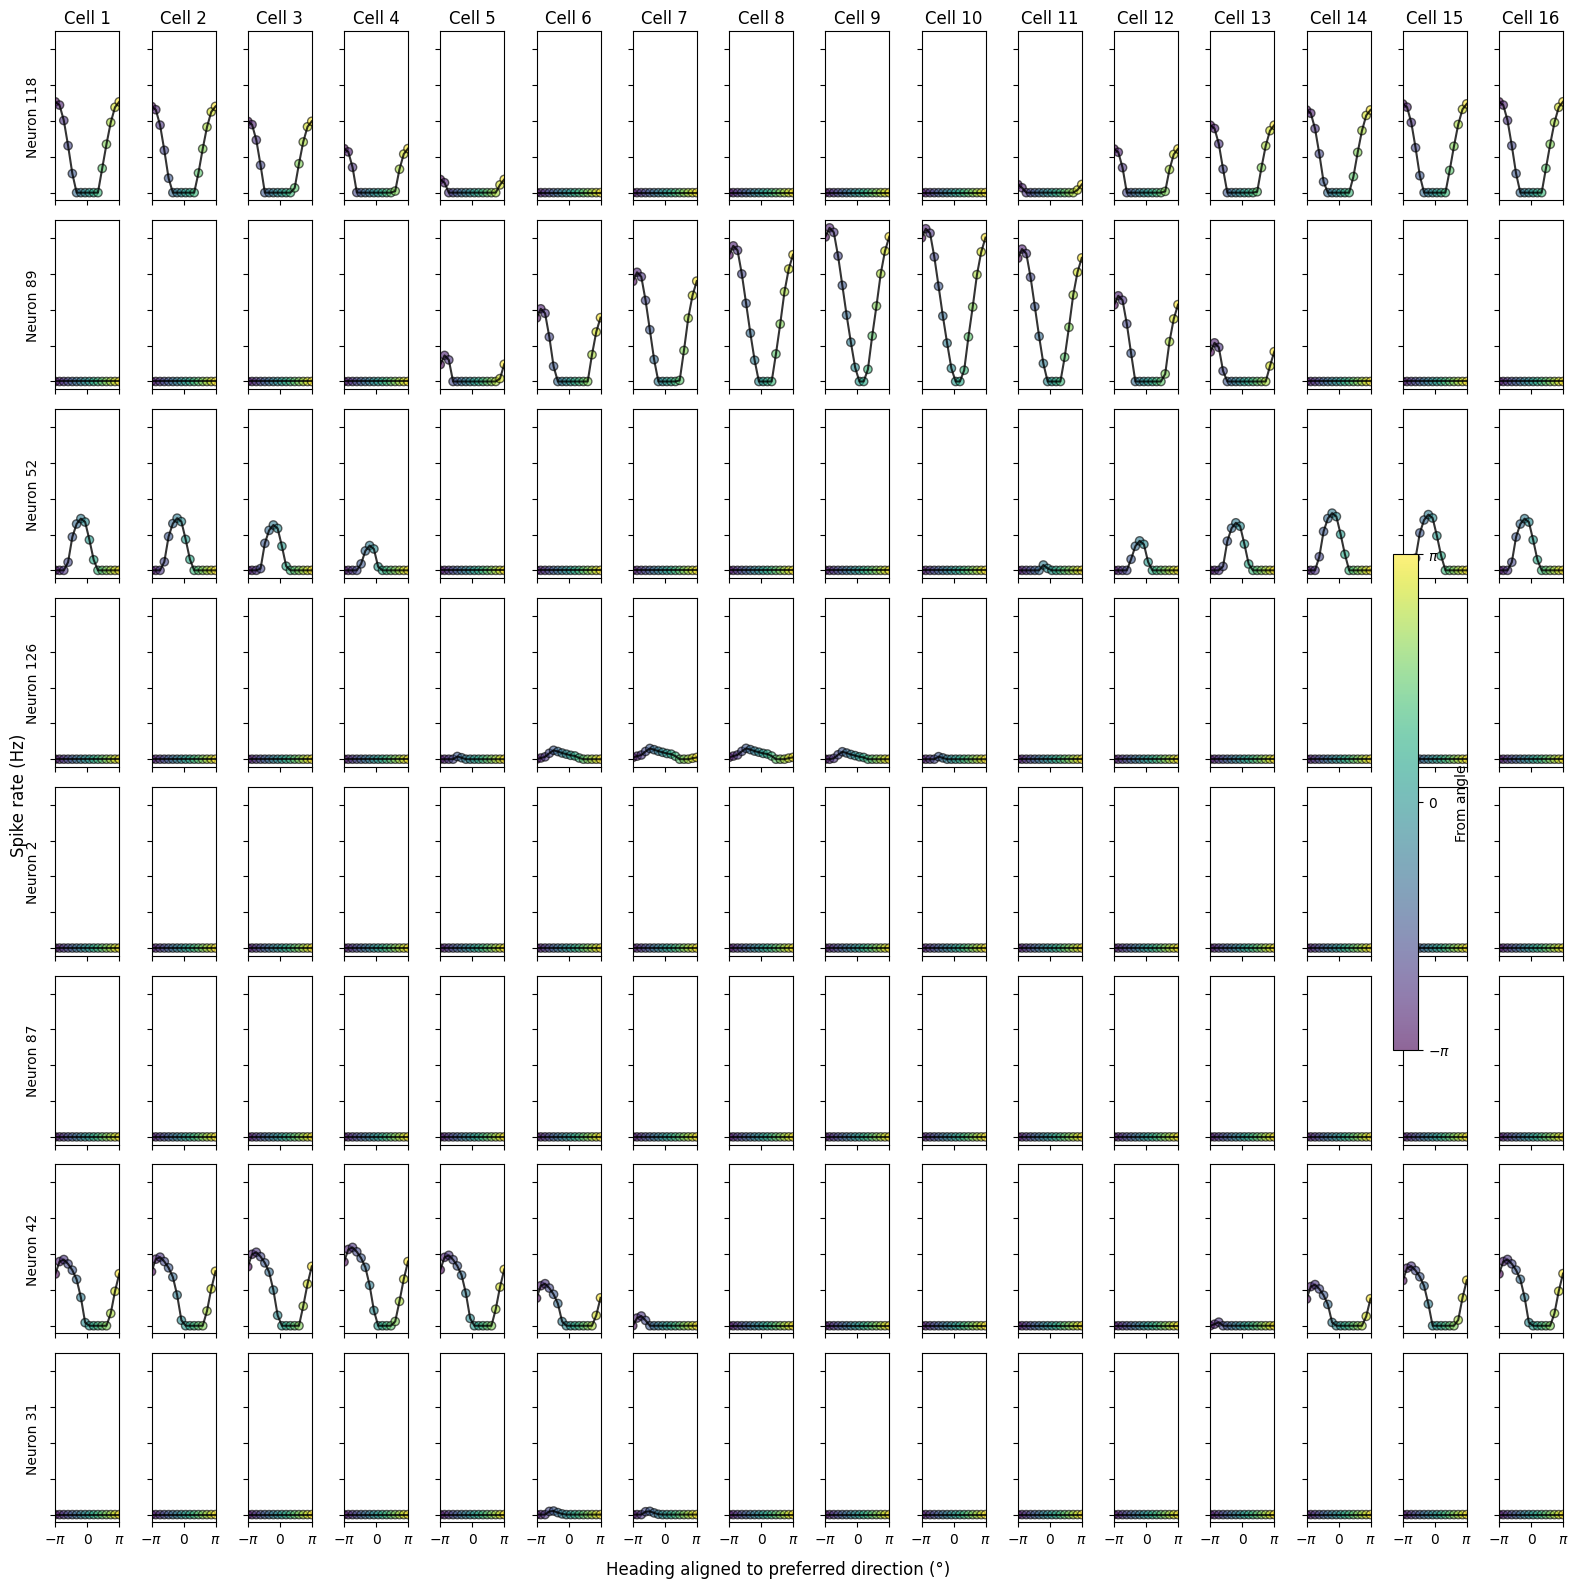

In [110]:
num_neurons = 8
neuron_ids = np.random.choice(ht.shape[2], size=num_neurons, replace=False)  # Randomly sample neurons

# Create the figure
fig, axes = plt.subplots(num_neurons, num_cells, figsize=(16, num_neurons * 2), sharex=True, sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, num_cells))  # Color map for each cell
norm = mcolors.Normalize(vmin=-np.pi, vmax=np.pi)  # Normalization for colorbar
ht = ht.cpu().detach()
for neuron_idx, neuron_id in enumerate(neuron_ids):
    spike_rates = [ht[i:i + num_samples, 0, neuron_id] for i in range(0, num_cells * num_samples, num_samples)]
    
    for cell_idx, (ax, rates) in enumerate(zip(axes[neuron_idx], spike_rates)):
        # Scatter plot (data points)
        scatter = ax.scatter(
            angles, rates, c=angles, cmap="viridis", norm=norm, alpha=0.6, edgecolor="black"
        )
        # Line plot (model)
        ax.plot(angles, rates, c="black", alpha=0.8, lw=1.5)

        # Aesthetic adjustments
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
        ax.set_xlim([-np.pi, np.pi])
        
        if neuron_idx < num_neurons - 1:
            ax.set_xticklabels([])  # Remove x-axis labels for all but the last row
        if cell_idx > 0:
            ax.set_yticklabels([])  # Remove y-axis labels for non-first columns

        # Label subplots
        if neuron_idx == 0:
            ax.set_title(f"Cell {cell_idx+1}")
        if cell_idx == 0:
            ax.set_ylabel(f"Neuron {neuron_id}")

# Shared labels
fig.supxlabel("Heading aligned to preferred direction (°)")
fig.supylabel("Spike rate (Hz)")

# Add a single colorbar for the entire figure
cbar = fig.colorbar(scatter, ax=axes, orientation="vertical", fraction=0.02, pad=0.05)
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels([r"$-\pi$", "0", r"$\pi$"])
cbar.set_label("From angle")

fig.tight_layout()
plt.show()


Now visualize 2D torus control neurons.

In [98]:
sample_from_num = 8 # squared, in the case of 2D
sample_to_num = 8
from_angle1 = np.linspace(-np.pi, np.pi, sample_from_num)
from_angle2 = np.linspace(-np.pi, np.pi, sample_from_num)
from_angle = np.stack(np.meshgrid(from_angle1, from_angle2), -1).reshape(-1, 2)
to_angle = from_angle.copy()
from_angle = np.repeat(from_angle, sample_to_num ** 2, axis = 0)
to_angle = np.tile(to_angle, [sample_to_num ** 2, 1])
from_reps = mapnet(torch.tensor(from_angle).to("cuda").float().reshape(-1, 2)).detach()
to_reps = mapnet(torch.tensor(to_angle).to("cuda").float().reshape(-1, 2)).detach()[:, -128:]
hi, control_trajectory, error_trajectory, ht = trainer.model(from_reps, to_reps, control_period = 16, return_control_trajectory=True)

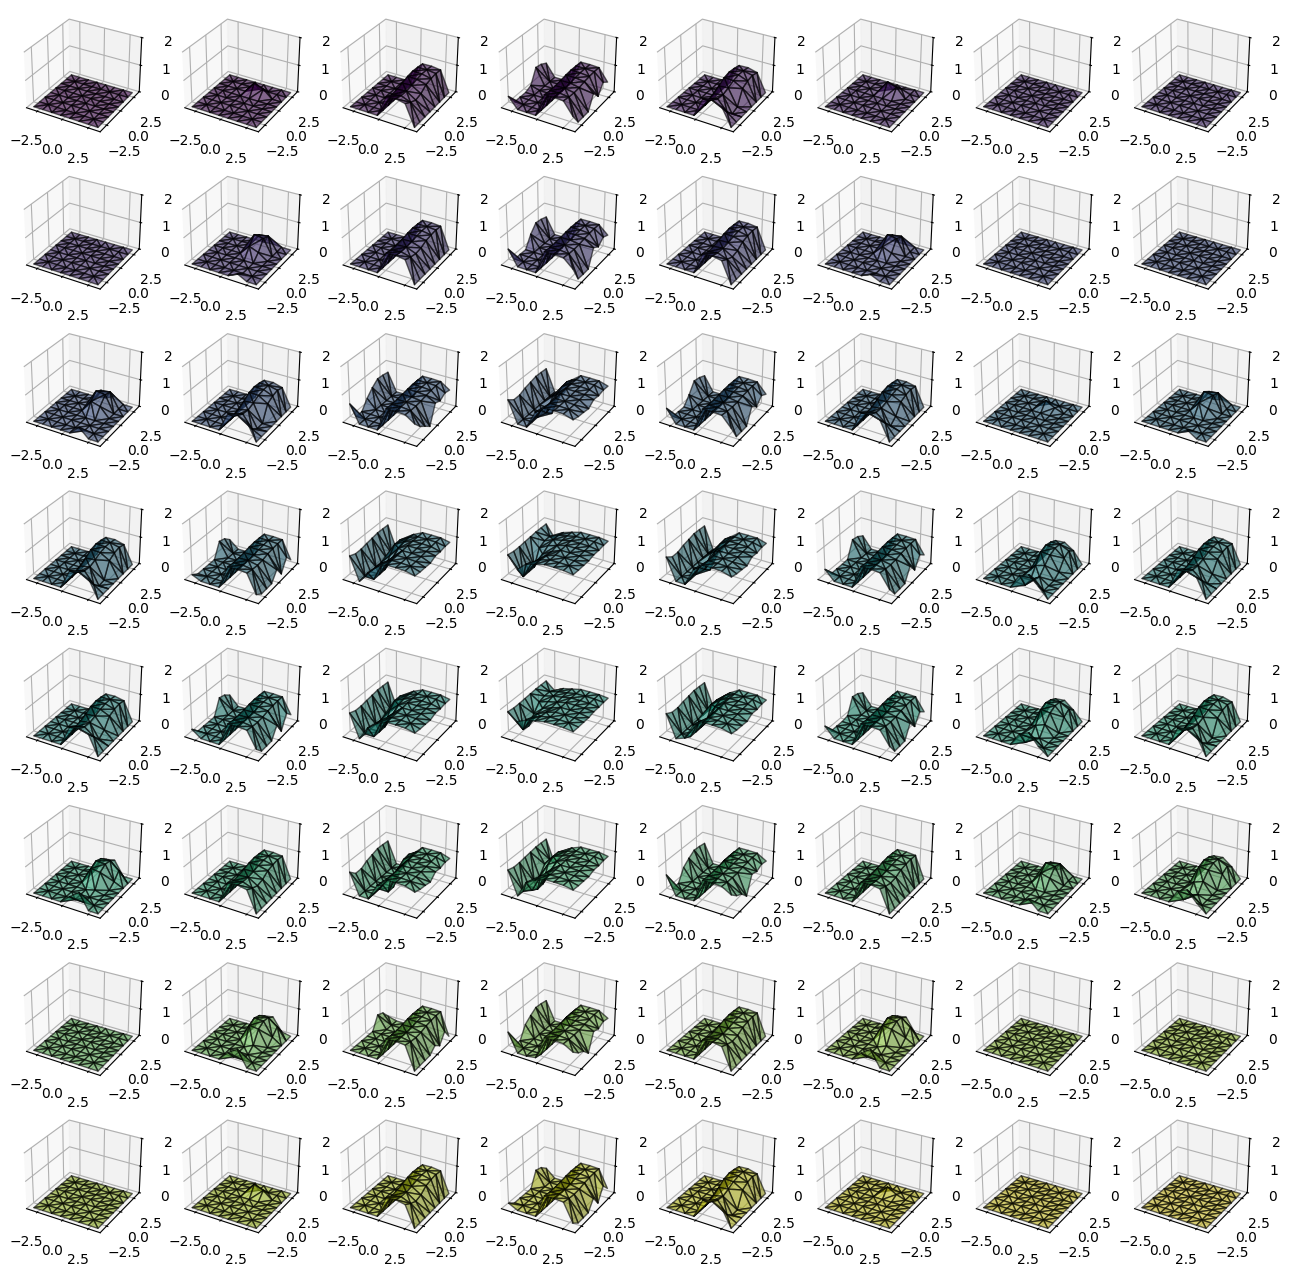

In [63]:

# neuron_id = np.random.randint(128)
# Simulated data
num_cells = 8  # Number of cells
num_samples = 8  # Number of samples
angles1 = np.linspace(-np.pi, np.pi, num_samples)  # Headings
angles2 = np.linspace(-np.pi, np.pi, num_samples)  # Headings
angles = np.stack(np.meshgrid(angles1, angles2), -1).reshape(-1, 2)
# a matrix of begin_angles

spike_rates = [ht[i:i + 64, 0, neuron_id].cpu().detach().numpy() for i in range(0, 4096, 64)]  # Spike rates

# Plotting
fig, axes = plt.subplots(num_cells, num_cells, figsize=(16, 16), subplot_kw={'projection': '3d'})

colors = plt.cm.viridis(np.linspace(0, 1, num_cells ** 2)) # Color map for each cell

for i, (ax, rates) in enumerate(zip(axes.flatten(), spike_rates)):
    
    ax.plot_trisurf(angles[:, 0], angles[:, 1], rates, color=colors[i], label="Data", alpha=0.6, edgecolor="black")
    ax.set_zlim([0, 2])
    # ax.plot(angles, rates, color=colors[i], label="Model", alpha=0.8, lw=2)

#     ax.set_xticks([-np.pi, 0, np.pi])
#     ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
#     ax.set_xlim([-np.pi, np.pi])
#     if i > 0:  # Remove y-axis labels for non-first plots
#         ax.set_yticklabels([])

#     # Label subplot
#     ax.set_title(f"Goal angle {angles[i]:.2f}")

# # Overall adjustments
# fig.supxlabel("Current angle")
# fig.supylabel("activation")
# fig.tight_layout()


plt.show()

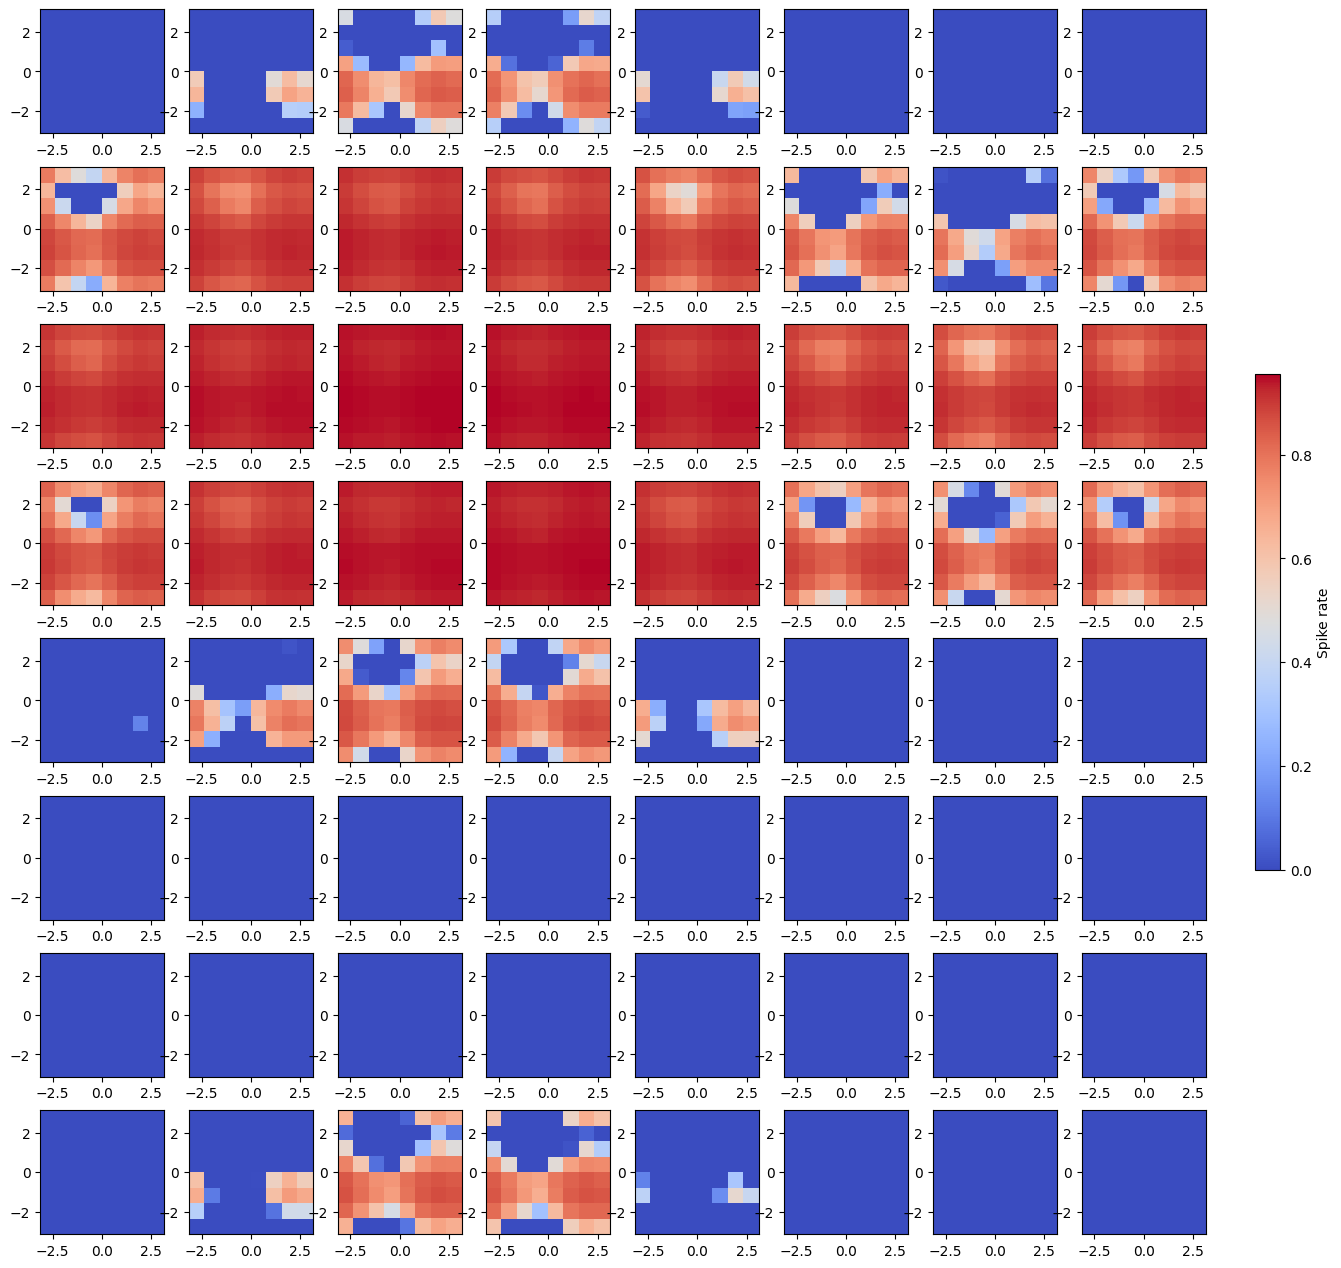

In [104]:
neuron_id = np.random.randint(128)
# Simulated data
num_cells = 8  # Number of cells
num_samples = 8  # Number of samples
angles1 = np.linspace(-np.pi, np.pi, num_samples)  # Headings
angles2 = np.linspace(-np.pi, np.pi, num_samples)  # Headings
angles = np.stack(np.meshgrid(angles1, angles2), -1).reshape(-1, 2)
# a matrix of begin_angles

spike_rates = [ht[i:i + num_cells**2, 0, neuron_id].cpu().detach().numpy() for i in range(0, num_cells ** 4, num_cells ** 2)]  # Spike rates

# Plotting
fig, axes = plt.subplots(num_cells, num_cells, figsize=(16, 16))

colors = plt.cm.viridis(np.linspace(0, 1, num_cells ** 2)) # Color map for each cell

# Normalize the color scale
norm = plt.Normalize(vmin=np.min(spike_rates), vmax=np.max(spike_rates))

for i, (ax, rates) in enumerate(zip(axes.flatten(), spike_rates)):
    firing_mat = rates.reshape(num_samples, num_samples)
    im = ax.imshow(firing_mat, cmap="coolwarm", origin="lower", extent=(-np.pi, np.pi, -np.pi, np.pi), norm=norm)

# Add a single colorbar for the entire figure
cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label("Spike rate")

plt.show()

In [103]:
spike_rates[0].shape

(64,)

Now, visualize the connectivity

plan: 
- use the mapnet to figure out tuning for each rep/input neuron in the rep net. 
- parse the connectivity implied by the controller, visualize the weight_matrix.
- rank by goal 
- color by connectivity to left vs. right motion output

In [52]:
angles = np.linspace(-np.pi, np.pi, 36)  # heading bins
firing = mapnet(torch.tensor(angles).unsqueeze(1).to("cuda").float()).detach()

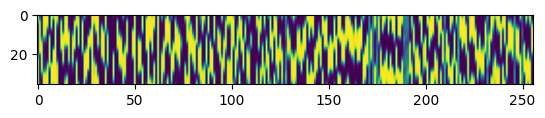

In [111]:
plt.imshow(firing.cpu().detach().numpy())

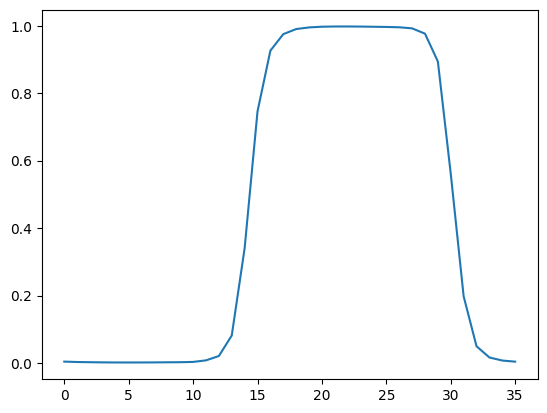

In [54]:
plt.plot(firing[:, -5].cpu().detach().numpy())

or, we can use the previously sampled X_train to check out reps. 

In [318]:
# bin X_train into 36 bins
bins = 36
X_train_binned = np.digitize(X_train, np.linspace(-np.pi, np.pi, bins))
X_train_binned = np.eye(bins)[X_train_binned - 1]
X_train_binned = torch.tensor(X_train_binned).to("cuda").float()

In [343]:
d = data_gen.generate_data(64, disregard_n_samples=False) if dim == 2 else data_gen.generate_data(10000, disregard_n_samples=False)
X_train = d.positions + (torch.randn_like(d.positions) < 0) * 2 * np.pi - (torch.randn_like(d.positions) < 0) * 2 * np.pi
rep_only = False
with torch.no_grad():
    Y_train = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]
X_train = X_train.cpu().numpy() if isinstance(X_train, torch.Tensor) else X_train
X_train = (X_train + np.pi) % (2 * np.pi) - np.pi
Y_train = Y_train.cpu().numpy() if isinstance(Y_train, torch.Tensor) else Y_train

# rank X_train based on position
rank = np.argsort(X_train, axis = 0)
X_train = X_train[rank]
Y_train = Y_train[rank]

# bin X_train and Y_train into 36 bins
bins = 37
X_train_binned = np.digitize(X_train, np.linspace(-np.pi, np.pi, bins))
# X_train_binned = np.eye(bins)[X_train_binned - 1]


tensor(0.0713, device='cuda:0', dtype=torch.float64)


In [344]:
X_train_binned[-1]

array([[36]])

In [350]:
#put Y_train into these bins
binned_avg_neural_activity = np.zeros((bins - 1, Y_train.shape[-1]))
bin_last = 1
bin_count = 0
for i, b in enumerate(X_train_binned): 
    if b != bin_last: 
        binned_avg_neural_activity[bin_last-1]/=bin_count
        bin_last = b
        bin_count = 0
    
    bin_count += 1
    binned_avg_neural_activity[b-1] += Y_train[i].reshape(-1)
binned_avg_neural_activity[bin_last-1]/=bin_count

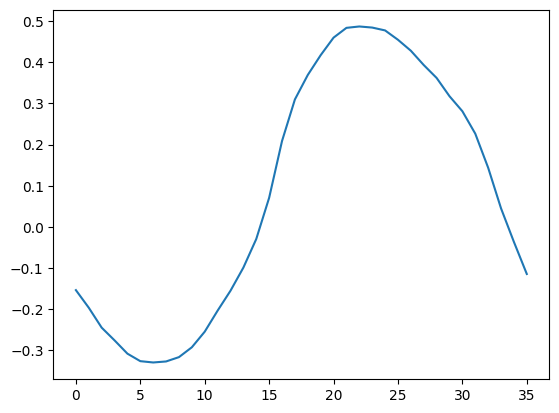

In [357]:
plt.plot(binned_avg_neural_activity[:, 1])

In [55]:
# so it looks the same either way. Then, we can endow neurons with preferred directions. 
preference = np.zeros(firing.shape[-1])
for i in range(firing.shape[-1]): 
    preference[i] = torch.argmax(firing[:, i])


In [113]:
W_xh = list(trainer.model.W_xh.parameters())[0].cpu().detach().numpy()
W_cxh = W_xh[:, :-128]
W_rxh = W_xh[:, -128:]
out_p = list(trainer.model.output_p.parameters())[0].cpu().detach().numpy()
out_m = list(trainer.model.output_m.parameters())[0].cpu().detach().numpy()

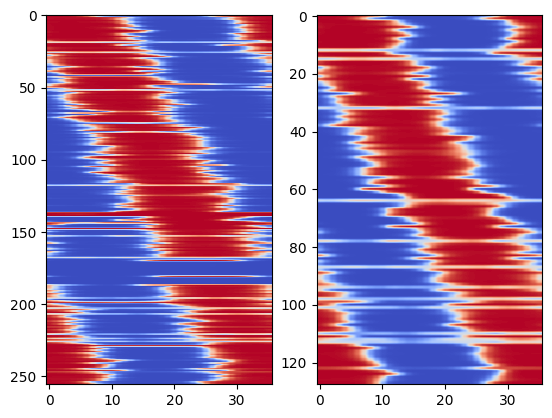

In [114]:
order1 = np.argsort(preference)
# make it a permutation matrix
order1 = np.eye(order1.shape[0])[order1]
fig, ax = plt.subplots(1, 2)
sorted_firing1 = order1 @ (firing.T.cpu().numpy())
# ax[0].imshow(sorted_firing1[128:], aspect="auto", cmap="coolwarm")
# order2 = np.argsort(preference[-128:])
# order2 = np.eye(order2.shape[0])[order2]
# sorted_firing2 = order2 @ (firing[:, -128:].T.cpu().numpy())
# ax[1].imshow(sorted_firing2[64:], aspect="auto", cmap="coolwarm")
ax[0].imshow(sorted_firing1[:], aspect="auto", cmap="coolwarm")
order2 = np.argsort(preference[-128:])
order2 = np.eye(order2.shape[0])[order2]
sorted_firing2 = order2 @ (firing[:, -128:].T.cpu().numpy())
ax[1].imshow(sorted_firing2[:], aspect="auto", cmap="coolwarm")



In [115]:
pm = out_p - out_m

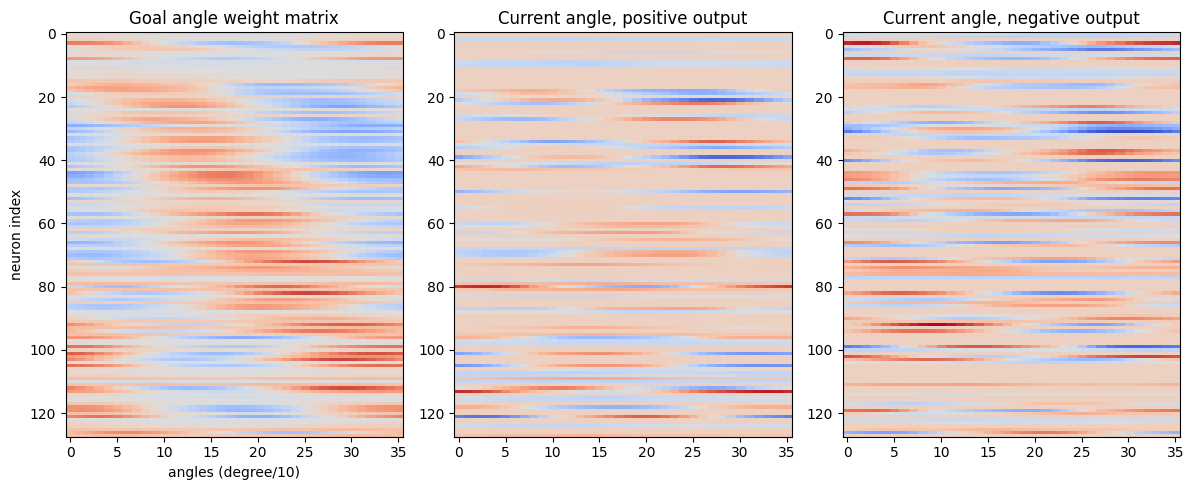

In [117]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
sorted_W_rxh = W_rxh @ order2[:, :].T
sorted_indices_W_rxh = np.argsort(sorted_W_rxh.argmax(axis=1))
order_W_rxh = np.eye(sorted_W_rxh.shape[0])[sorted_indices_W_rxh]
ordered_cxw = order_W_rxh @ W_cxh @ order1[:, :].T @ sorted_firing1[:]

ordered_cxw_p =  (pm > 0).reshape(128, 1) * ordered_cxw
ordered_cxw_m = (pm < 0).reshape(128, 1) * ordered_cxw
ordered_cxw_p = (ordered_cxw_p - ordered_cxw_p.min()) / (ordered_cxw_p.max() - ordered_cxw_p.min())
ordered_cxw_m = (ordered_cxw_m - ordered_cxw_m.min()) / (ordered_cxw_m.max() - ordered_cxw_m.min())

ordered_rxw = order_W_rxh @ sorted_W_rxh @ sorted_firing2[:]
ordered_rxw = (ordered_rxw - ordered_rxw.min()) / (ordered_rxw.max() - ordered_rxw.min())

# im1 = ax[0].imshow(order_W_rxh @ sorted_W_rxh @ sorted_firing2[:], aspect="auto", cmap="coolwarm")
# im2 = ax[1].imshow(ordered_cxw_p, aspect="auto", cmap="coolwarm")
# im3 = ax[2].imshow(ordered_cxw_m, aspect="auto", cmap="coolwarm")

# Normalize the color scale based on the combined data range
vmin = min(ordered_rxw.min(), ordered_cxw_p.min(), ordered_cxw_m.min())
vmax = max(ordered_rxw.max(), ordered_cxw_p.max(), ordered_cxw_m.max())

im1 = ax[0].imshow(ordered_rxw, aspect="auto", cmap="coolwarm", vmin=vmin, vmax=vmax)
im2 = ax[1].imshow(ordered_cxw_p, aspect="auto", cmap="coolwarm", vmin=vmin, vmax=vmax)
im3 = ax[2].imshow(ordered_cxw_m, aspect="auto", cmap="coolwarm", vmin=vmin, vmax=vmax)

# Add a single colorbar for the entire figure
fig.colorbar(im1, ax=ax, orientation='vertical', fraction=.02, pad=0.04)

ax[0].set_xlabel("angles (degree/10)")
ax[0].set_title("Goal angle weight matrix")
ax[1].set_title("Current angle, positive output")
ax[2].set_title("Current angle, negative output")
ax[0].set_ylabel("neuron index")

plt.tight_layout()
plt.show()


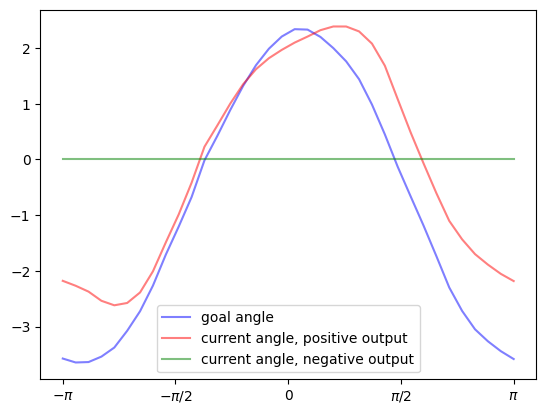

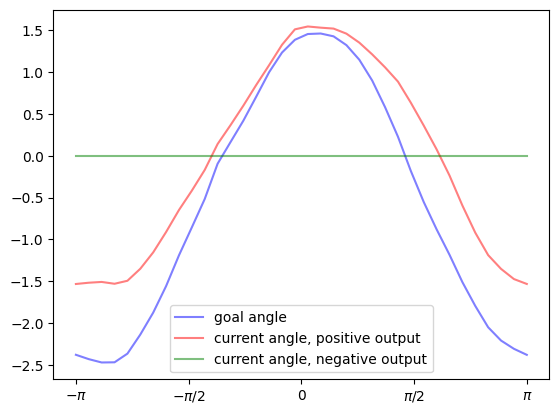

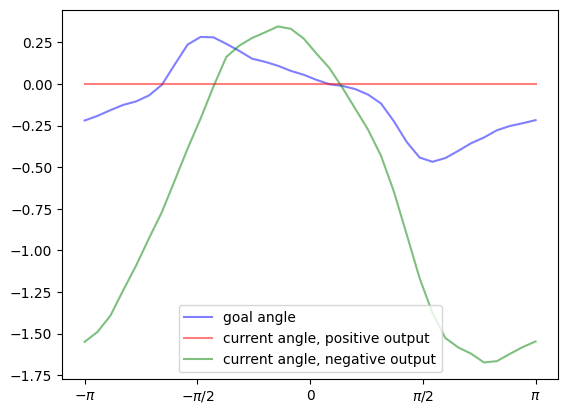

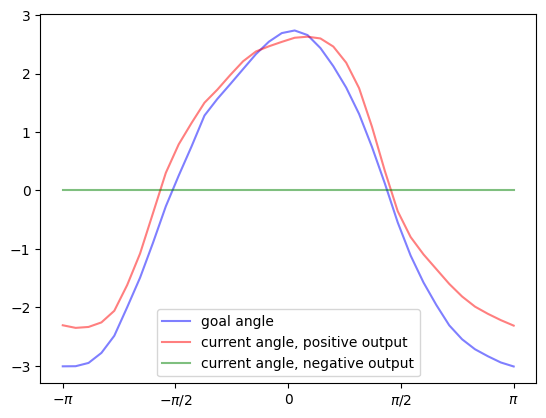

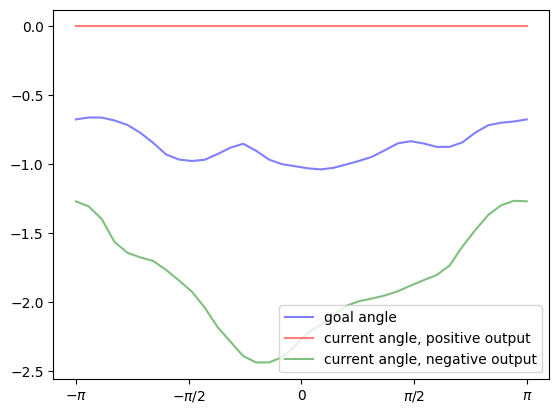

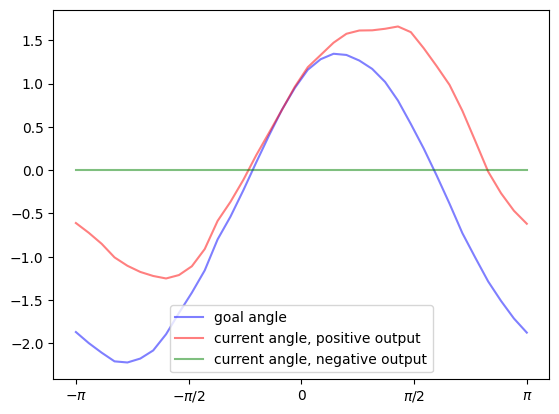

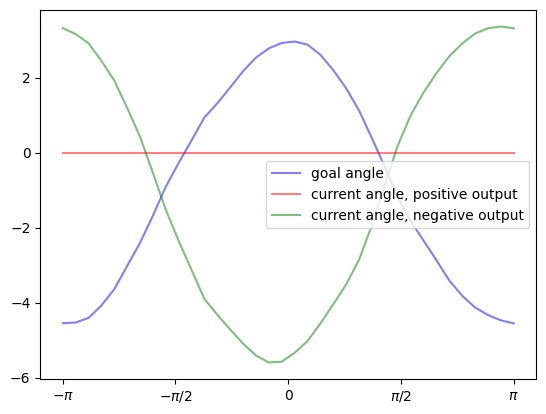

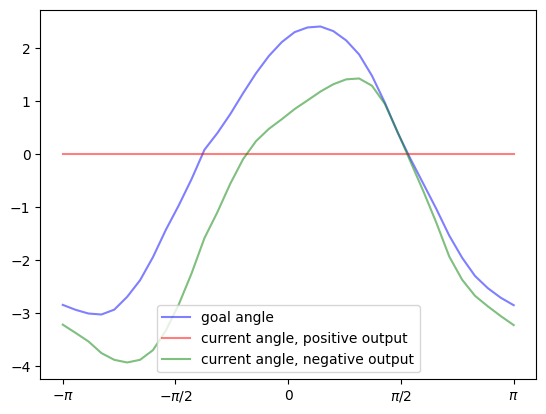

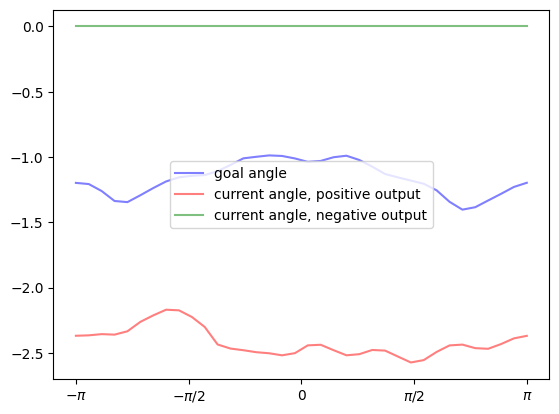

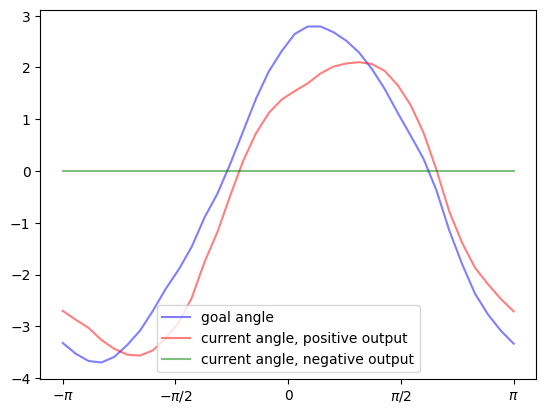

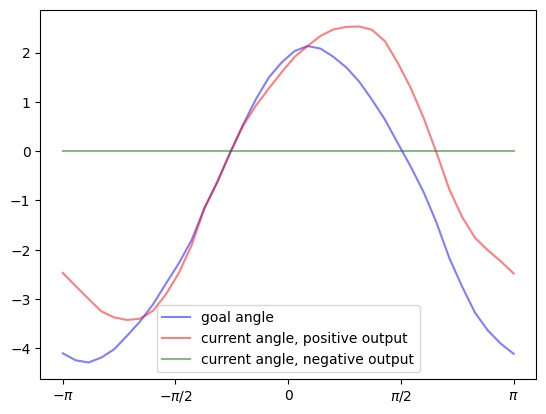

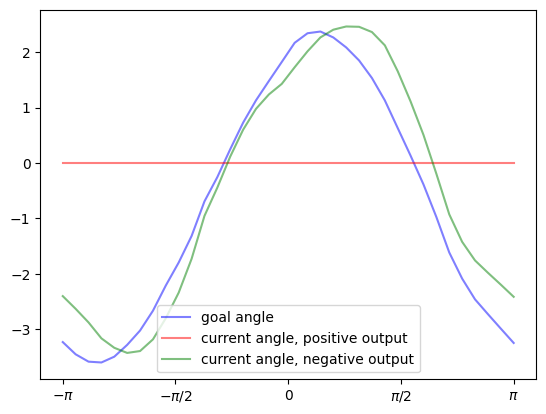

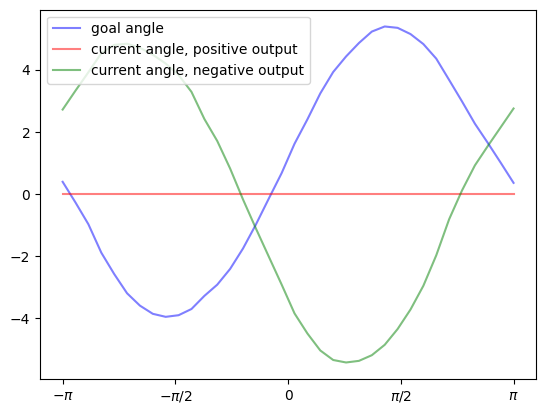

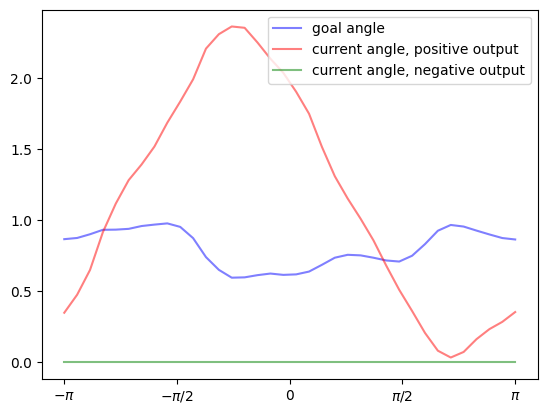

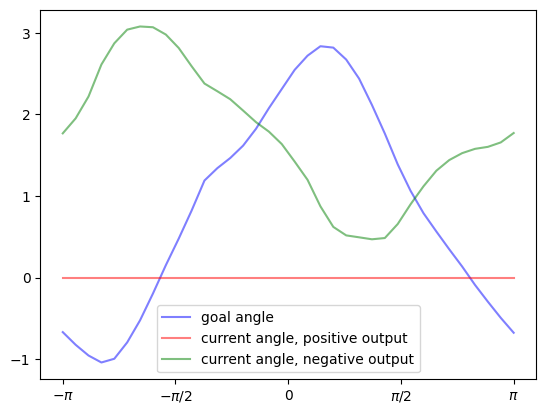

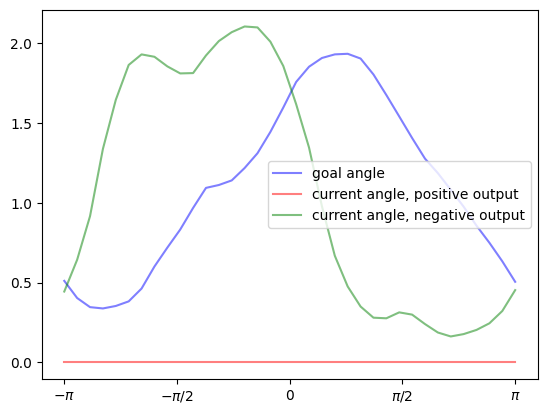

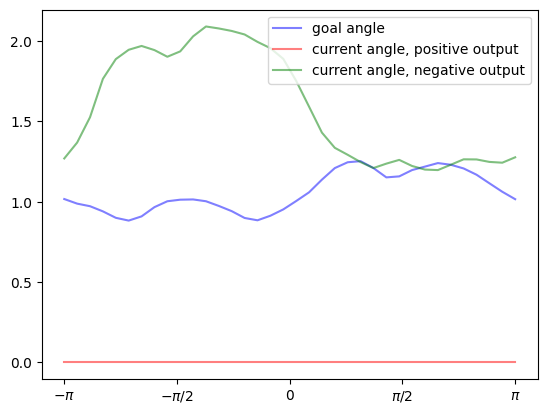

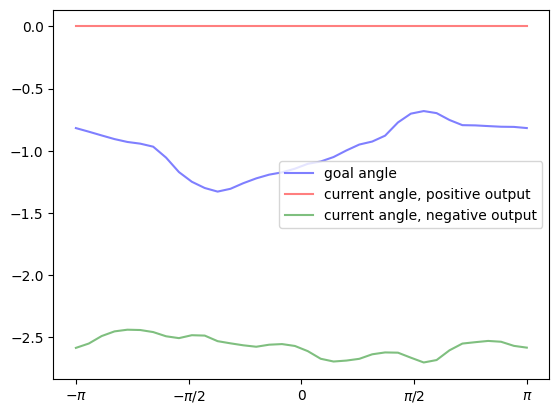

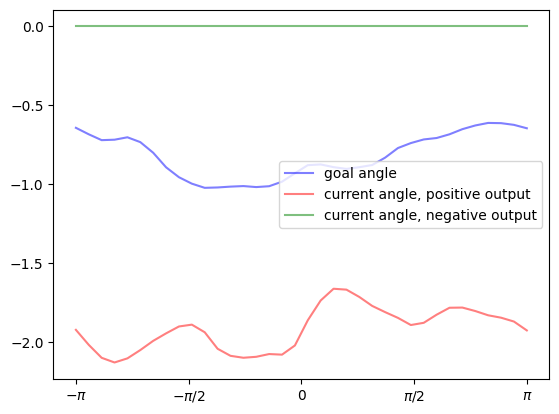

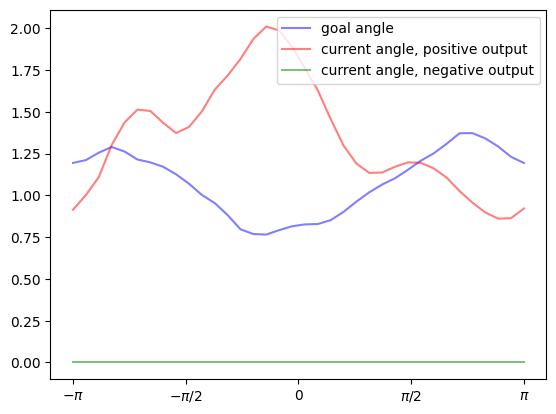

In [120]:
# now, the above plot is not very informative. Let's try to plot individual neurons using the matrices
for i in range(60, 80): 
    max_direction = np.argmax(ordered_rxw[i])
    # shift the row so that the max direction is at the center
    # plt.plot(np.roll(ordered_rxw[i], -max_direction + 16), c = "blue", alpha = 0.5)
    # plt.plot(np.roll(ordered_cxw_p[i], -max_direction + 16), c = "red", alpha = 0.5)
    # plt.plot(np.roll(ordered_cxw_m[i], -max_direction + 16), c = "green", alpha = 0.5)
    plt.plot(ordered_rxw[i], c = "blue", alpha = 0.5)
    plt.plot(ordered_cxw_p[i], c = "red", alpha = 0.5)
    plt.plot(ordered_cxw_m[i], c = "green", alpha = 0.5)

    plt.xticks(
        np.linspace(0, 35, 5), 
        [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"]
    )
    plt.legend(["goal angle", "current angle, positive output", "current angle, negative output"])
    plt.show()

In [117]:
# plot tuning curve: 
sample_from_num = 64
sample_to_num = 64
from_angle = np.linspace(-np.pi, np.pi, sample_from_num)
from_angle = np.repeat(from_angle, sample_to_num)
to_angle = np.linspace(-np.pi, np.pi, sample_to_num)
to_angle = np.tile(to_angle, sample_from_num)
from_reps = mapnet(torch.tensor(from_angle).to("cuda").float().reshape(-1, 1)).detach()
to_reps = mapnet(torch.tensor(to_angle).to("cuda").float().reshape(-1, 1)).detach()[:, -128:]

hi, control_trajectory, error_trajectory, ht = trainer.model(from_reps, to_reps, control_period = 16, return_control_trajectory=True)

In [102]:
sorted_W_rxh.shape

(128, 64)

In [91]:
sorted_indices_W_rxh.shape

(128, 64)

In [84]:
W_rxh.shape

(128, 128)

In [ ]:
order1

array([127, 106, 202, 203, 101, 100,  98,  97,  96,  95, 206,  93, 207,
        89,  87, 195, 211, 213,  83,  82,  81, 214, 157,  78, 215,  76,
        75, 216,  73,  72,  71,  85, 193, 191, 112, 156, 155, 162, 152,
       151, 150, 165, 147, 145, 167, 142, 168, 139, 138, 170, 171, 133,
       113, 190, 116, 189, 120, 181,  70, 180, 126, 175, 128, 129, 174,
       173, 125,  69,  79, 236,  34, 234, 235,  68,  30,  29,  28,  27,
       237,  24,  23, 239, 241,  20, 242, 244,  16, 249,   2,   3,   4,
         5, 248,  35, 247,   9,  10, 246,  13,  14, 245,   8, 232, 158,
        49, 218,  62,  60, 219, 222,  56, 224, 225, 226,  64,  48, 229,
        46, 217,  45,  44,  38, 231,  40,  41,  42,  39,  11, 185, 199,
        66,  90, 136,  50, 163, 114, 209,  51, 187,  61, 109, 186, 137,
        37, 179,  25, 210, 104, 143, 221, 172, 153, 169,  55, 205, 110,
        18,  67, 166,   0, 121, 103, 118,  32,  31,  74, 131, 201,  65,
        43,  36, 200,  91, 141,   6, 135, 161,  21,  19,   1, 11

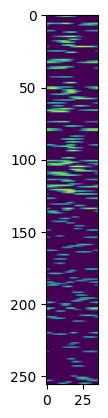

In [64]:
plt.imshow(firing.T.cpu().numpy())

In [58]:
firing.shape

torch.Size([36, 256])

In [ ]:
# the next step is to use this lookup table to visualize the control weights
bins = 37
W_xh = list(trainer.model.W_xh.parameters())[0].cpu().detach().numpy()
W_cxh = W_xh[:, :-128]
W_rxh = W_xh[:, -128:]
out_p = list(trainer.model.output_p.parameters())[0].cpu().detach().numpy()
out_m = list(trainer.model.output_m.parameters())[0].cpu().detach().numpy()
print(W_xh.shape, out_p.shape, out_m.shape)
W_cxh_angles = np.zeros((W_cxh.shape[0], bins - 1))
W_rxh_angles = np.zeros((W_rxh.shape[0], bins - 1))
for i in range(W_cxh.shape[1]): 
    W_cxh_angles[:, int(preference[i])] = W_cxh[:, i] + W_cxh_angles[:, int(preference[i])]

for i in range(W_rxh.shape[1]): 
    W_rxh_angles[:, int(preference[-128+i])] = W_rxh[:, i] + W_rxh_angles[:, int(preference[-128+i])]

(128, 384) (1, 128) (1, 128)


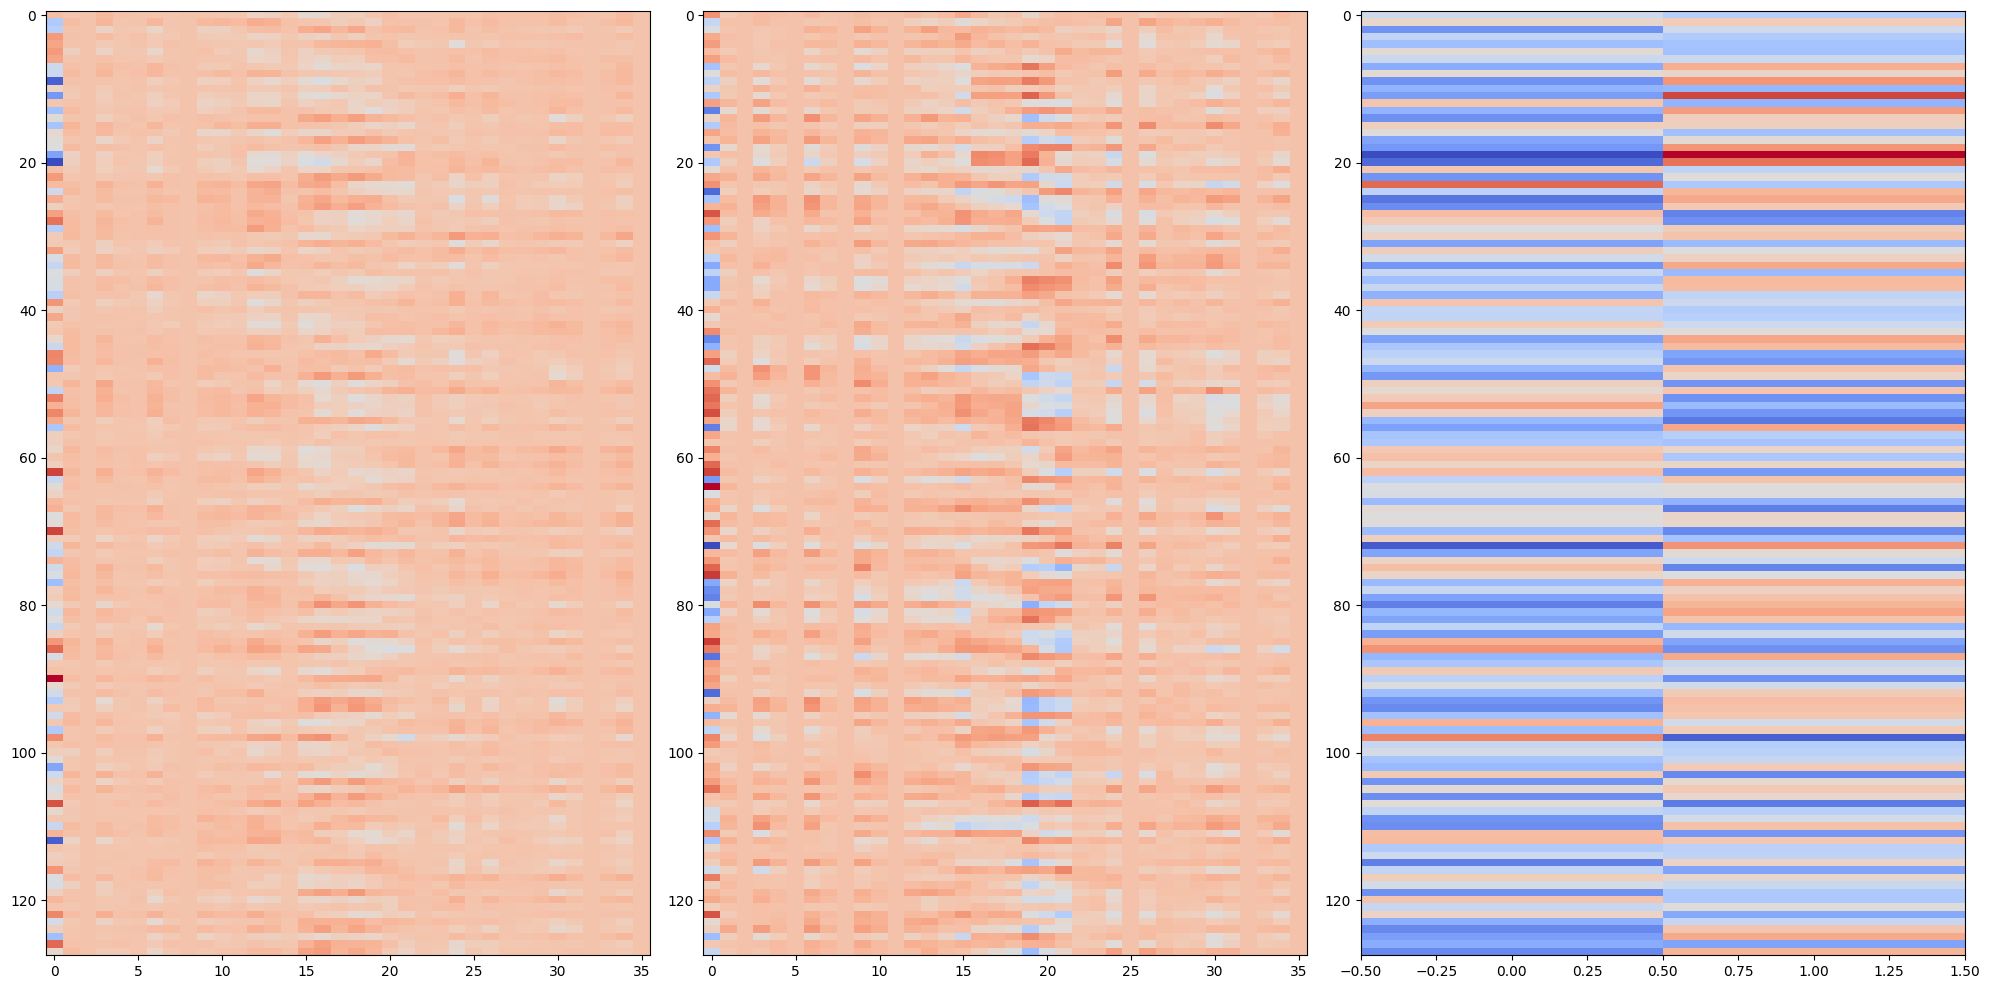

In [48]:
W_big = np.concatenate((W_cxh_angles, W_rxh_angles, out_p.T, out_m.T), axis = 1)
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
ax[0].imshow(W_cxh_angles, aspect="auto", cmap="coolwarm")
ax[1].imshow(W_rxh_angles, aspect="auto", cmap="coolwarm")
ax[2].imshow(np.concatenate((out_p.T, out_m.T), axis = 1), aspect="auto", cmap="coolwarm")
plt.tight_layout()